In [1]:
import asyncio
from xbbg import blp
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
# Fetch S&P 500 constituents
spx_members_nw = await blp.abds('SPX Index', 'INDX_MEMBERS')
spx_members_df = spx_members_nw.to_pandas()
print(f"Number of S&P 500 members retrieved: {len(spx_members_df)}")

# Extract the list of tickers, adding ' Equity' to the end as Bloomberg expects it for equity tickers
member_tickers = [str(t) + " Equity" for t in spx_members_df['Member Ticker and Exchange Code'] if str(t)]
print(f"\nFirst 5 tickers formatted for Bloomberg: {member_tickers[:5]}")

Number of S&P 500 members retrieved: 503

First 5 tickers formatted for Bloomberg: ['A UN Equity', 'AAPL UW Equity', 'ABBV UN Equity', 'ABNB UW Equity', 'ABT UN Equity']


In [3]:
# Fetch historical daily last prices (PX_LAST) for WTI Crude and all SPX members
start_date = '2020-01-01'

print("Fetching historical price data from Bloomberg...")
# Combining oil ticker with company tickers
tickers = ['CL1 Comdty'] + member_tickers

# Fetching the data asynchronously
hist_data_nw = await blp.abdh(tickers, 'PX_LAST', start_date=start_date)
hist_data = hist_data_nw.to_pandas()

print(f"Data fetched! Shape: {hist_data.shape}")
print(hist_data.head())

Fetching historical price data from Bloomberg...


Data fetched! Shape: (770552, 4)
         ticker        date    field   value
0  CB UN Equity  2020-01-02  PX_LAST  156.02
1  CB UN Equity  2020-01-03  PX_LAST  155.78
2  CB UN Equity  2020-01-06  PX_LAST  157.06
3  CB UN Equity  2020-01-07  PX_LAST  153.92
4  CB UN Equity  2020-01-08  PX_LAST  152.87


In [4]:
# Pivot the data to wide format (dates as index, tickers as columns)
price_df = hist_data.pivot(index='date', columns='ticker', values='value')

# Ensure the index is datetime
price_df.index = pd.to_datetime(price_df.index)

# Calculate daily percentage returns
returns_df = price_df.pct_change().dropna(how='all')

print(f"Returns DataFrame shape: {returns_df.shape}")

# Separate oil returns and stock returns
oil_returns = returns_df['CL1 Comdty']
stock_returns = returns_df.drop(columns=['CL1 Comdty'], errors='ignore')

# Calculate the correlation between each stock's return and the oil price return
correlations = stock_returns.corrwith(oil_returns).dropna()

# Sort the correlations to find the most exposed companies
sorted_corrs = correlations.sort_values(ascending=False)

print("\nTop 10 Companies Most POSITIVELY Exposed to Oil Prices (Positive Correlation):")
print(sorted_corrs.head(10))

print("\nTop 10 Companies Most NEGATIVELY Exposed to Oil Prices (Negative Correlation):")
print(sorted_corrs.tail(10))

C:\Users\nklannfonteyne1\AppData\Local\Temp\ipykernel_13644\2482226466.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = price_df.pct_change().dropna(how='all')


Returns DataFrame shape: (1584, 504)



Top 10 Companies Most POSITIVELY Exposed to Oil Prices (Positive Correlation):
ticker
APA UW Equity     0.561117
BKR UW Equity     0.385431
EXE UW Equity     0.324548
XOM UN Equity     0.233940
OXY UN Equity     0.231320
COP UN Equity     0.223322
CVX UN Equity     0.222710
FANG UW Equity    0.212409
OKE UN Equity     0.205940
EOG UN Equity     0.205851
dtype: float64

Top 10 Companies Most NEGATIVELY Exposed to Oil Prices (Negative Correlation):
ticker
KVUE UN Equity   -0.050503
EQT UN Equity    -0.052021
EVRG UW Equity   -0.053324
MRNA UW Equity   -0.055797
COO UW Equity    -0.060763
SOLV UN Equity   -0.065308
VLTO UN Equity   -0.071353
WMT UW Equity    -0.182913
KMB UW Equity    -0.263598
Q UN Equity      -0.350070
dtype: float64


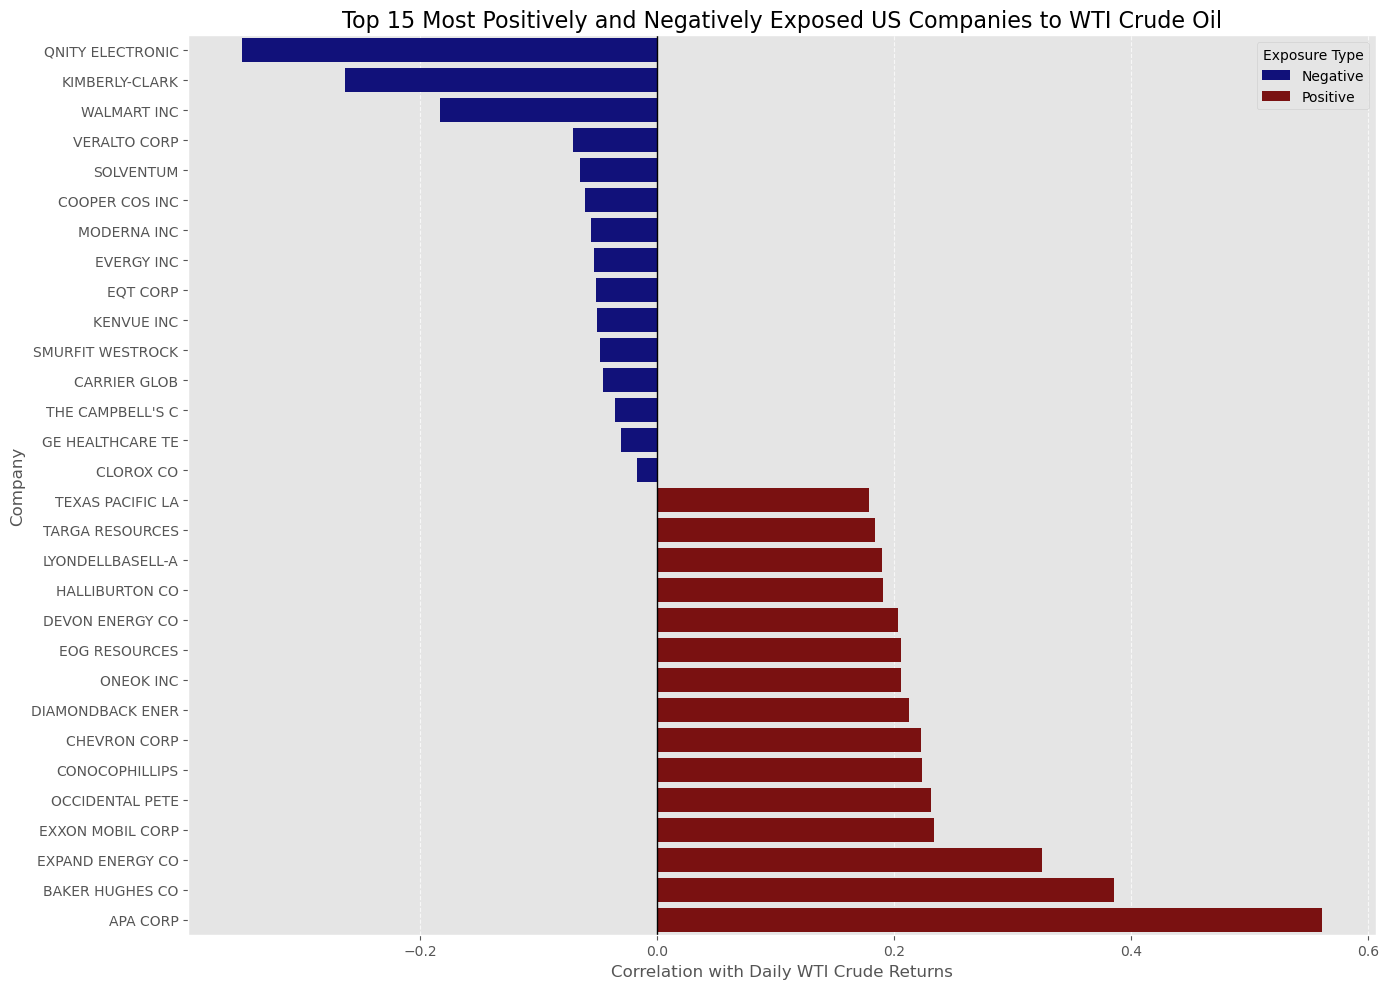

In [5]:
# Get the top 15 positive and top 15 negative
top_positive = sorted_corrs.head(15)
top_negative = sorted_corrs.tail(15).sort_values(ascending=True) # Sort ascending so the most negative is first

extremes = pd.concat([top_positive, top_negative])

# Fetch company names for readability
extreme_tickers = extremes.index.tolist()
names_nw = await blp.abdp(extreme_tickers, 'SHORT_NAME')
names_df = names_nw.to_pandas()

# Map tickers to names
name_map = dict(zip(names_df['ticker'], names_df['value']))

# Create a final dataframe for plotting
plot_df = pd.DataFrame({
    'Ticker': extremes.index,
    'Correlation': extremes.values,
    'Company Name': [name_map.get(t, t) for t in extremes.index]
})

# Adding an Exposure Type column for coloring
plot_df['Exposure Type'] = ['Positive' if c > 0 else 'Negative' for c in plot_df['Correlation']]

# Sort for plotting: most negative to most positive
plot_df = plot_df.sort_values('Correlation')

# Create the plot
plt.figure(figsize=(14, 10))
sns.barplot(
    data=plot_df, 
    x='Correlation', 
    y='Company Name', 
    hue='Exposure Type',
    palette={'Positive': 'darkred', 'Negative': 'darkblue'}
)

plt.title('Top 15 Most Positively and Negatively Exposed US Companies to WTI Crude Oil', fontsize=16)
plt.xlabel('Correlation with Daily WTI Crude Returns', fontsize=12)
plt.ylabel('Company', fontsize=12)
plt.axvline(x=0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Conclusion: US Companies' Exposure to Oil Prices

**Methodology:**
We analyzed the daily percentage returns of S&P 500 constituents against the daily percentage returns of WTI Crude Oil (`CL1 Comdty`) from 2020 to present. We calculated the Pearson correlation coefficient between the daily returns to measure exposure.

**Findings:**
1. **Most Positively Exposed (Direct Beneficiaries):** Unsurprisingly, the companies with the highest positive correlation to oil prices are concentrated in the **Energy and Oilfield Services sectors**. Companies like APA Corp, Baker Hughes, Exxon Mobil, Occidental Petroleum, and ConocoPhillips see their stock prices rise most reliably alongside crude oil due to higher margins on their core products.
2. **Most Negatively Exposed (Inverse Relationship):** Companies most negatively affected by rising oil prices are found in the **Consumer Goods, Retail, and Healthcare sectors**. Notable names include Walmart, Kimberly-Clark, and Kenvue. For these companies, higher oil prices translate directly into increased transportation, logistics, and manufacturing costs, which squeezes profit margins and pressures their stock performance.

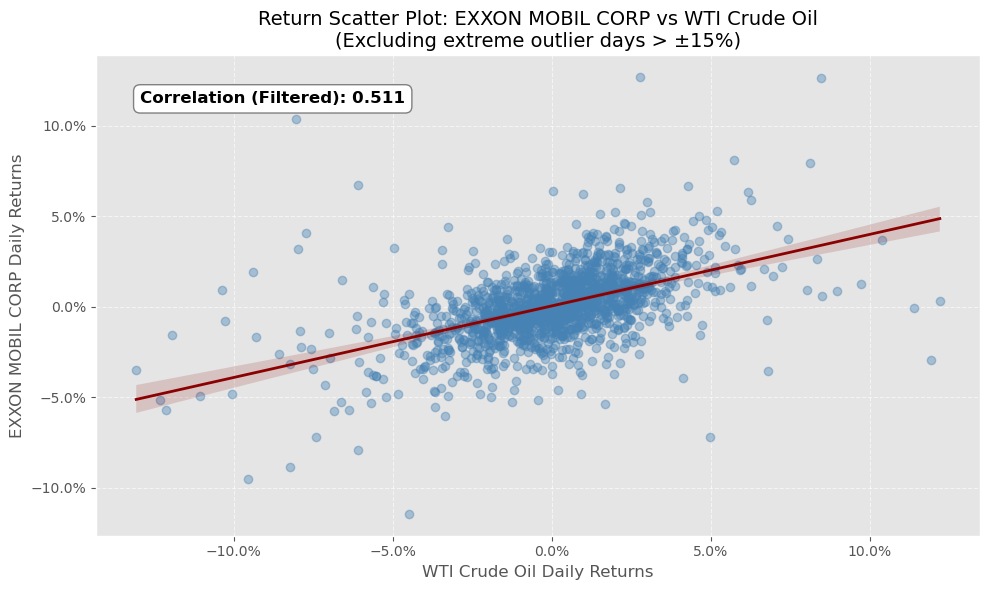

In [6]:
# --- INDIVIDUAL COMPANY SCATTER PLOT ---
# Set the company ticker you want to analyze here
company_ticker = 'XOM UN Equity'  # Example: Exxon Mobil (XOM UN Equity) or 'WMT UW Equity' (Walmart)

if company_ticker in returns_df.columns:
    # Fetch company name for the title
    try:
        name_nw = await blp.abdp([company_ticker], 'SHORT_NAME')
        name_df = name_nw.to_pandas()
        company_name = name_df['value'].iloc[0] if not name_df.empty else company_ticker
    except Exception:
        company_name = company_ticker
        
    plt.figure(figsize=(10, 6))
    
    # FILTER OUTLIERS: Early 2020 had extreme oil price anomalies (including negative prices).
    # A -300% daily return completely skews the chart and trendline. 
    # We will filter to only include days where the WTI return was between -15% and +15%.
    valid_days = returns_df[(returns_df['CL1 Comdty'] >= -0.15) & (returns_df['CL1 Comdty'] <= 0.15)].copy()
    
    # Create the scatter plot with a linear regression line using the filtered data
    sns.regplot(
        x=valid_days['CL1 Comdty'], 
        y=valid_days[company_ticker], 
        scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
        line_kws={'color': 'darkred', 'linewidth': 2}
    )
    
    plt.title(f'Return Scatter Plot: {company_name} vs WTI Crude Oil\n(Excluding extreme outlier days > ±15%)', fontsize=14)
    plt.xlabel('WTI Crude Oil Daily Returns', fontsize=12)
    plt.ylabel(f'{company_name} Daily Returns', fontsize=12)
    
    # Calculate and display the correlation coefficient on the plot
    corr_val = valid_days['CL1 Comdty'].corr(valid_days[company_ticker])
    plt.annotate(
        f'Correlation (Filtered): {corr_val:.3f}', 
        xy=(0.05, 0.90), 
        xycoords='axes fraction', 
        fontsize=12, 
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1)
    )
    
    # Format axes as percentages
    import matplotlib.ticker as mtick
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print(f"Ticker '{company_ticker}' not found in the dataset. Please ensure it's formatted properly (e.g., 'AAPL UW Equity').")

In [7]:
# Fetch GICS Sector for all members
print("Fetching sector information for all companies...")
sectors_nw = await blp.abdp(member_tickers, 'GICS_SECTOR_NAME')
sectors_df = sectors_nw.to_pandas()

# Create a mapping of ticker to sector
sector_map = dict(zip(sectors_df['ticker'], sectors_df['value']))

# Create a DataFrame with correlations and sectors
sector_analysis_df = pd.DataFrame({
    'Ticker': correlations.index,
    'Correlation': correlations.values,
    'Sector': [sector_map.get(t, 'Unknown') for t in correlations.index]
})

# Calculate average correlation per sector
sector_summary = sector_analysis_df.groupby('Sector')['Correlation'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

print("\nAverage Correlation to Oil by Sector:")
print(sector_summary)

Fetching sector information for all companies...



Average Correlation to Oil by Sector:
                            mean       std  count
Sector                                           
Energy                  0.204330  0.115607     22
Real Estate             0.090885  0.034715     31
Materials               0.084815  0.049371     26
Financials              0.082211  0.029522     76
Utilities               0.082113  0.038684     31
Industrials             0.076442  0.035571     79
Consumer Discretionary  0.068516  0.028594     48
Information Technology  0.060975  0.056335     73
Communication Services  0.056763  0.026429     23
Health Care             0.043828  0.040149     58
Consumer Staples        0.030197  0.077141     36


C:\Users\nklannfonteyne1\AppData\Local\Temp\ipykernel_13644\4169442789.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


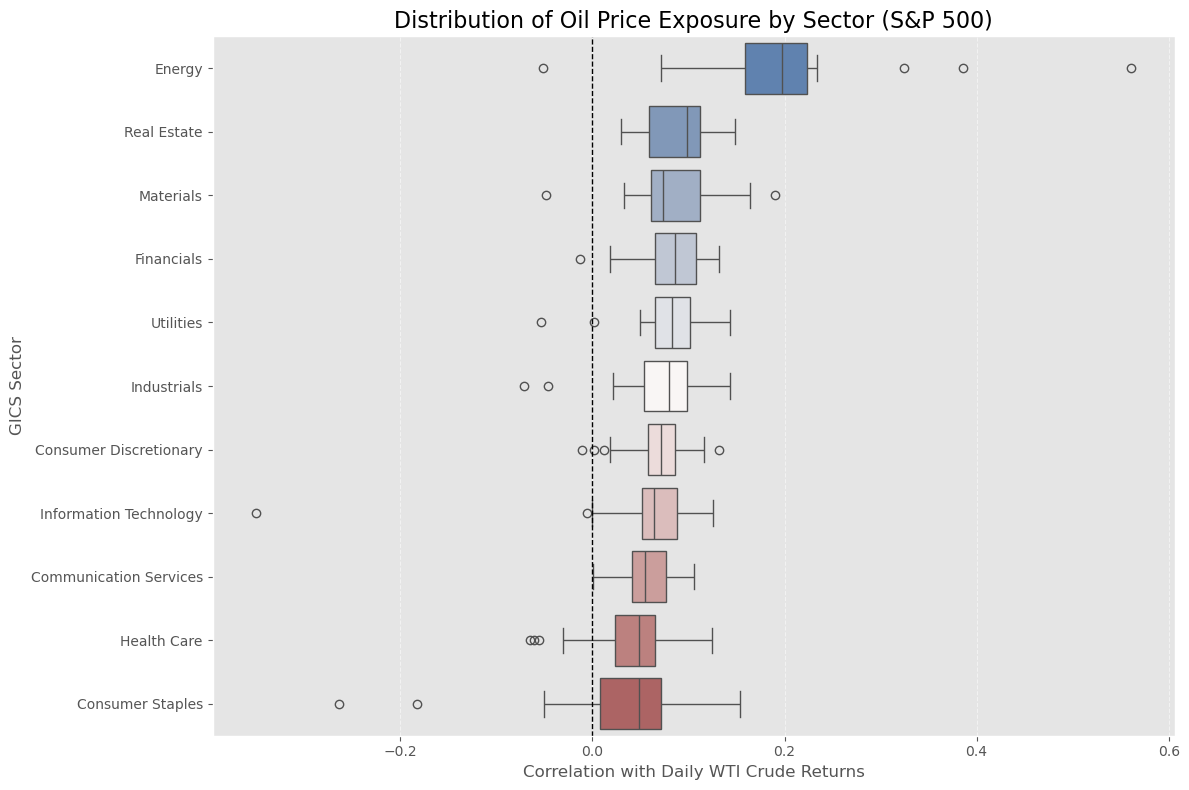

In [8]:
# Visualize correlation distribution by Sector
plt.figure(figsize=(12, 8))

# Order sectors by mean correlation
sector_order = sector_analysis_df.groupby('Sector')['Correlation'].mean().sort_values(ascending=False).index

sns.boxplot(
    data=sector_analysis_df, 
    x='Correlation', 
    y='Sector', 
    order=sector_order,
    palette='vlag'
)

plt.title('Distribution of Oil Price Exposure by Sector (S&P 500)', fontsize=16)
plt.xlabel('Correlation with Daily WTI Crude Returns', fontsize=12)
plt.ylabel('GICS Sector', fontsize=12)
plt.axvline(x=0, color='black', linewidth=1, linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()